In [20]:
import pandas as pd
def read_data():
    for i in range(2,151,2):
        yield pd.read_feather(f'./data{i}.feather').set_index('id')
df = pd.concat(read_data(), ignore_index=True)

In [21]:
df

,width,depth,size,max_subcircuit_width,two_gates,cluster_cut_num,cluster_subcircuit_num,cluster_time,MIP_cut_num,MIP_subcircuit_num,MIP_time
0,8,73,112,3,52,13.0,7,0.096558,0,0,1.015214
1,8,73,112,4,52,9.0,5,0.142353,4,3,1.563126
2,8,73,112,5,52,7.0,3,0.108084,4,3,1.456583
3,8,73,112,6,52,6.0,3,0.122381,4,2,0.453616
4,8,73,112,7,52,9.0,3,0.082669,4,2,0.400416
...,...,...,...,...,...,...,...,...,...,...,...
1495,31,62,798,30,240,8.0,2,1.325868,8,2,14.330430
1496,31,82,1258,3,390,536.0,189,7.412029,0,0,0.153512
1497,31,82,1258,4,390,351.0,96,5.945672,0,0,0.158327
1498,31,82,1258,5,390,284.0,64,5.238262,0,0,0.157483


In [15]:
df.width.unique()

array([ 8, 16,  7, 24, 11, 32, 15, 40, 19, 48, 23, 56, 27, 64, 31])

<Axes: xlabel='size', ylabel='cluster_time'>

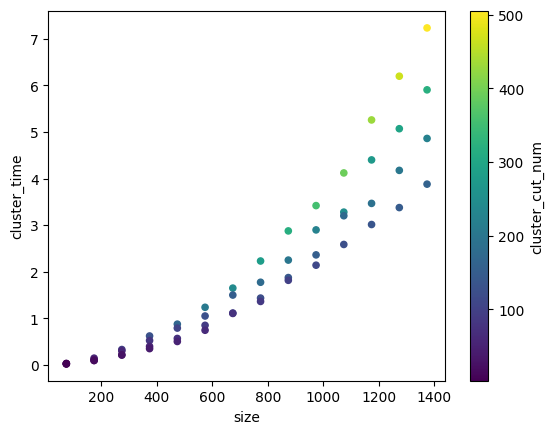

In [22]:
df[df['width']==7].plot.scatter(x='size',y='cluster_time',c='cluster_cut_num',colormap='viridis')

In [23]:
name = pd.read_feather('./dataname.feather')

In [24]:
df['name'] = name['name']

In [25]:
df['name'] = df['name'].str.replace('\d+', '')
df['name'] = df['name'].str.replace('_', '')

/var/folders/yl/f78zmr7d24n8y70v98h117ww0000gn/T/ipykernel_50227/2142633885.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df['name'] = df['name'].str.replace('\d+', '')


In [33]:
df[df['MIP_cut_num']==0]

,width,depth,size,max_subcircuit_width,two_gates,cluster_cut_num,cluster_subcircuit_num,cluster_time,MIP_cut_num,MIP_subcircuit_num,MIP_time,name
0,8,73,112,3,52,13.0,7,0.096558,0,0,1.015214,RCAdder
5,16,165,260,3,120,29.0,15,0.545443,0,0,4.262818,RCAdder
6,16,165,260,4,120,29.0,13,0.594823,0,0,11.655539,RCAdder
18,7,18,74,3,18,17.0,8,0.032772,0,0,0.116234,HWEA
19,7,18,74,4,18,8.0,4,0.029764,0,0,2.294580,HWEA
...,...,...,...,...,...,...,...,...,...,...,...,...
1480,31,62,798,15,240,39.0,5,1.472865,0,0,900.968438,HWEA
1496,31,82,1258,3,390,536.0,189,7.412029,0,0,0.153512,HWEA
1497,31,82,1258,4,390,351.0,96,5.945672,0,0,0.158327,HWEA
1498,31,82,1258,5,390,284.0,64,5.238262,0,0,0.157483,HWEA


In [27]:
grouped = df.groupby('name')
HWEA = grouped.get_group('HWEA')
grouped.groups.keys()

dict_keys(['HWEA', 'RCAdder'])

<Axes: xlabel='size', ylabel='cluster_time'>

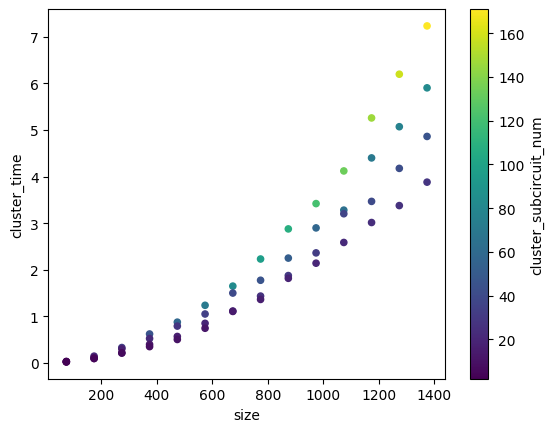

In [29]:
HWEA[HWEA['width']==7].plot.scatter(x='size',y='cluster_time',c='cluster_subcircuit_num',colormap='viridis')

In [8]:
HWEA_valid= HWEA[HWEA['MIP_cut_num']>0]
HWEA_valid

,width,depth,size,max_subcircuit_width,two_gates,cluster_cut_num,cluster_subcircuit_num,cluster_time,MIP_cut_num,MIP_subcircuit_num,MIP_time,name
20,7,18,74,5,18,3.0,2,0.022966,3,2,0.177865,HWEA
21,7,18,74,6,18,3.0,2,0.023718,3,2,0.143862,HWEA
97,11,22,118,5,30,14.0,5,0.059329,9,4,3.428418,HWEA
98,11,22,118,6,30,6.0,3,0.060895,6,3,1.051514,HWEA
99,11,22,118,7,30,3.0,2,0.057520,3,2,0.330183,HWEA
...,...,...,...,...,...,...,...,...,...,...,...,...
1491,31,62,798,26,240,8.0,2,1.260013,8,2,11.052080,HWEA
1492,31,62,798,27,240,8.0,2,1.343763,8,2,6.300862,HWEA
1493,31,62,798,28,240,8.0,2,1.319211,8,2,7.137599,HWEA
1494,31,62,798,29,240,8.0,2,1.225150,8,2,12.294623,HWEA


In [10]:
# mip 不能切割的benchmark 占比
1-len(HWEA_valid)/len(HWEA)

0.877831715210356

In [13]:
HWEA_valid['speedup'] = HWEA_valid['MIP_time']/HWEA_valid['cluster_time']

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_18929/346870682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HWEA_valid['speedup'] = HWEA_valid['MIP_time']/HWEA_valid['cluster_time']


In [29]:
len(list(df.groupby('name')))
len(list(HWEA_valid.groupby('width')))

7

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_18929/1171192189.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  HWEA_valid['speedup'] = HWEA_valid['MIP_time']/HWEA_valid['cluster_time']


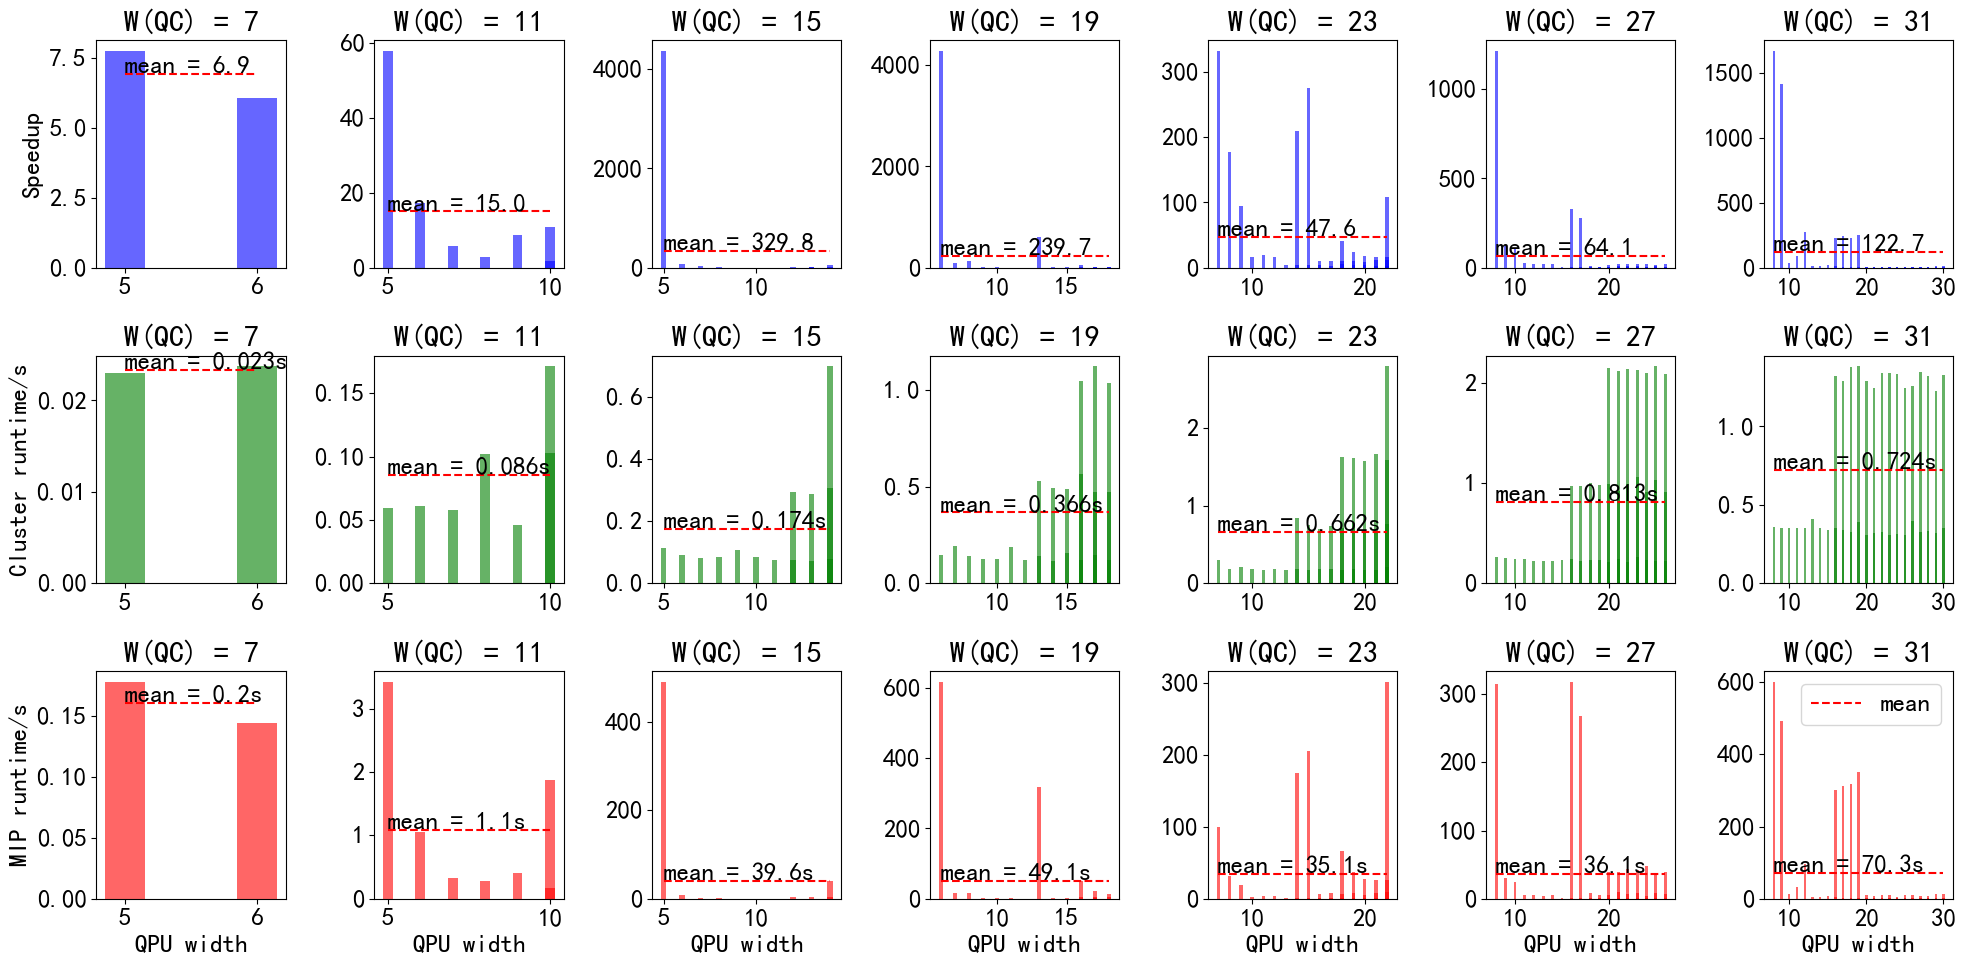

In [47]:
# 创建画布和子图
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(3, len( HWEA_valid.groupby('width')), figsize=(20, 10))
HWEA_valid['speedup'] = HWEA_valid['MIP_time']/HWEA_valid['cluster_time']
# 在每个子图中绘制折线图
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 18
i = 0
axs[0,i].set_ylabel('Speedup',fontsize=18)
axs[1,i].set_ylabel('Cluster runtime/s',fontsize=18)
axs[2,i].set_ylabel('MIP runtime/s',fontsize=18)
for (width,data) in  HWEA_valid.groupby('width'):
    x = data['max_subcircuit_width']
    y= data['speedup']
    axs[0,i].bar(x, y,alpha=0.6,width=0.3,color='b')
    axs[0,i].hlines(xmin=min(x),xmax=max(x),y=np.mean(y),linestyles='--',colors='r',label='mean')
    axs[0,i].annotate('mean = {:.1f}'.format(np.mean(y)),xy=(min(x),np.mean(y)))
    axs[0,i].set_title('W(QC) = '+str(width))
    y = data['cluster_time']
    axs[1,i].bar(x, y,alpha=0.6,width=0.3,color='g')
    axs[1,i].hlines(xmin=min(x),xmax=max(x),y=np.mean(y),linestyles='--',colors='r',label='mean')
    axs[1,i].annotate('mean = {:.3f}s'.format(np.mean(y)),xy=(min(x),np.mean(y)))
    axs[1,i].set_title('W(QC) = '+str(width))
    y = data['MIP_time']
    axs[2,i].bar(x, y,alpha=0.6,width=0.3,color='r')
    axs[2,i].hlines(xmin=min(x),xmax=max(x),y=np.mean(y),linestyles='--',colors='r',label='mean')
    axs[2,i].annotate('mean = {:.1f}s'.format(np.mean(y)),xy=(min(x),np.mean(y)))
    axs[2,i].set_title('W(QC) = '+str(width))
    axs[2,i].set_xlabel('QPU width',fontsize=18)
    i+=1
fig.tight_layout()
# 显示图形
plt.legend()
plt.savefig('Runtime.png',dpi=300)

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_18929/691618504.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfvalid['speedup'] = dfvalid['MIP_time']/dfvalid['cluster_time']


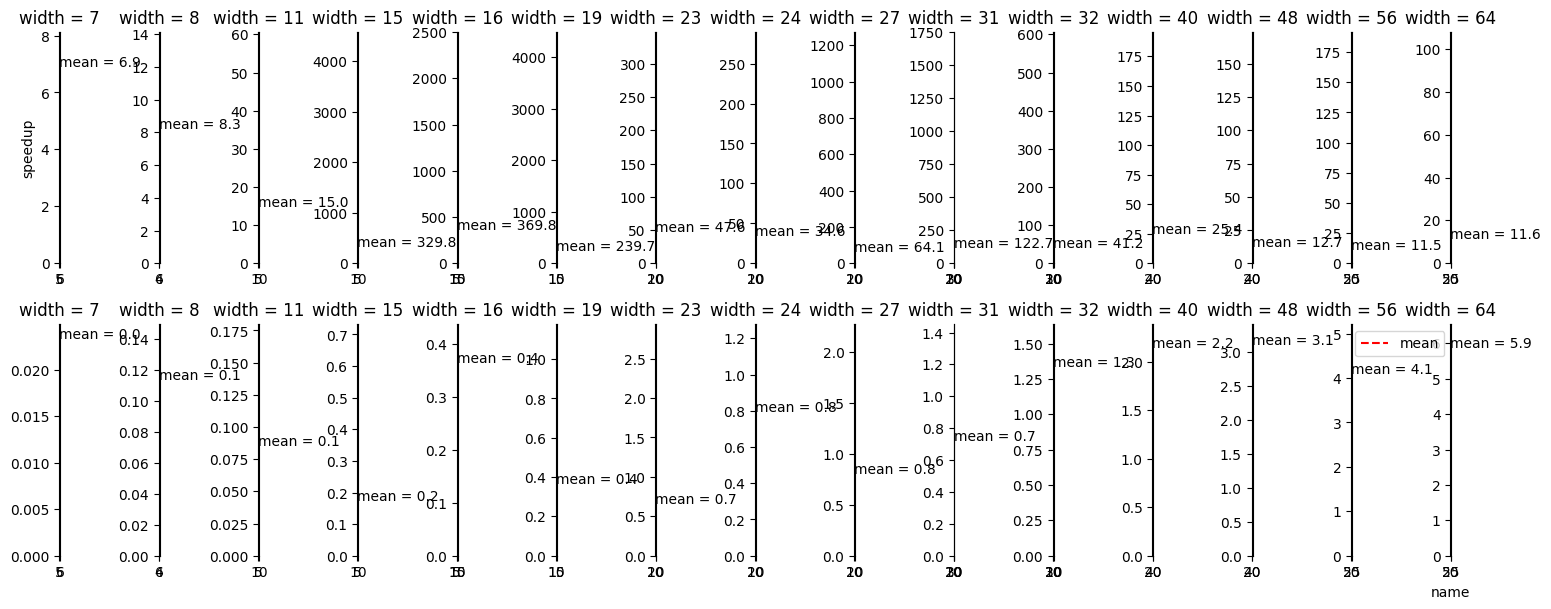

In [33]:
# 创建画布和子图
import matplotlib.pyplot as plt
import numpy as np
dfvalid = df[df['MIP_cut_num']>0]
fig, axs = plt.subplots(2, len( dfvalid.groupby('width')), figsize=(15, 6))
dfvalid['speedup'] = dfvalid['MIP_time']/dfvalid['cluster_time']
# 在每个子图中绘制折线图
i = 0
axs[0,i].set_ylabel('speedup')
for (width,data) in  dfvalid.groupby('width'):
    x = data['max_subcircuit_width']
    y= data['speedup']
    axs[0,i].bar(x, y,alpha=0.6,width=0.5)
    axs[0,i].hlines(xmin=min(x),xmax=max(x),y=np.mean(y),linestyles='--',colors='r',label='mean')
    axs[0,i].annotate('mean = {:.1f}'.format(np.mean(y)),xy=(min(x),np.mean(y)))
    axs[0,i].set_title('width = '+str(width))
    y = data['cluster_time']
    axs[1,i].bar(x, y,alpha=0.6,width=0.5,color='r')
    axs[1,i].hlines(xmin=min(x),xmax=max(x),y=np.mean(y),linestyles='--',colors='r',label='mean')
    axs[1,i].annotate('mean = {:.1f}'.format(np.mean(y)),xy=(min(x),np.mean(y)))
    axs[1,i].set_title('width = '+str(width))
    i+=1
fig.tight_layout()
# 显示图形
plt.xlabel('name')
plt.legend()
plt.show()
# plt.savefig('speedup.png',dpi=600)

In [ ]:
# 创建画布和子图
import matplotlib.pyplot as plt
import numpy as np
fig, axs = plt.subplots(1, len( HWEA_valid.groupby('width')), figsize=(15, 3))
for name, dfdata in df.groupby('name'):
    dfvalid = dfdata[dfdata['MIP_cut_num']>0]
# 在每个子图中绘制折线图
i = 0
axs[i].set_ylabel('speedup')
for (width,data) in  HWEA_valid.groupby('width'):
    x = data['max_subcircuit_width']
    y= data['speedup']
    axs[i].bar(x, y,alpha=0.6,width=0.5)
    axs[i].hlines(xmin=min(x),xmax=max(x),y=np.mean(y),linestyles='--',colors='r',label='mean')
    axs[i].annotate('mean = {:.1f}'.format(np.mean(y)),xy=(min(x),np.mean(y)))
    axs[i].set_title('width = '+str(width))
    i+=1
fig.tight_layout()
# 显示图形
plt.xlabel('name')
plt.legend()
plt.show()
plt.savefig('speedup.png',dpi=600)